# Channel Cohort Quality and Discount Reliance

This notebook is the follow-up analysis to the slide titled **"Deep discounting destroys cohort quality"**.

The prior slide establishes the commercial symptom:

| Pointer from the image | What it says | Why this notebook follows up |
|---|---|---|
| Revenue fell from the 2021 peak while discounts rose materially. | The business is paying more discount dollars while total revenue has not recovered to the 2021 level. | We need to identify whether this is uniform across the customer base or concentrated in specific acquisition channels. |
| Unique customers recovered by 2025, but revenue/customer fell sharply. | More customers are not translating into better customer value. | We need to compare channels by **quality**, not only by acquisition volume. |
| The slide warns about weaker repeat buyers. | The concern is not just acquisition count; it is whether customers come back without needing another discount. | This notebook uses **full-price repeat within 365 days** as the stricter loyalty signal. |
| The image frames a discount/cohort-quality issue. | The wording is directionally useful for the story, but the analysis should remain descriptive. | This notebook phrases findings as observed associations, not causal proof. |

## Follow-Up Question

If the business is acquiring more customers at lower average value, **which channels are contributing to that lower-quality growth, and how dependent are those channels on discounts?**

The notebook answers this using only `EDA/outputs` and focuses on:

- channel cohort quality: year-1 revenue/customer, repeat within 365 days, full-price repeat within 365 days
- channel discount reliance: first-order discount exposure, year-1 discounted-order share, year-1 discount rate
- which charts and talking points should go into the follow-up slide

In [1]:
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

try:
    from IPython.display import display, Markdown
except Exception:
    display = print
    Markdown = lambda x: x

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
OUTPUT_DIR = PROJECT_ROOT / "EDA" / "outputs"

DATA_SOURCES = {
    "orders": OUTPUT_DIR / "orders.parquet",
    "customers": OUTPUT_DIR / "customers.parquet",
    "lines": OUTPUT_DIR / "lines.parquet",
    "channel_quality_reference": OUTPUT_DIR / "05_channel_quality.csv",
}
for name, path in DATA_SOURCES.items():
    assert path.exists(), f"Missing {name}: {path}"
source_text = "\n".join(str(p) for p in DATA_SOURCES.values()).lower()
for forbidden in [("data", "gold"), ("data", "silver")]:
    assert "/".join(forbidden) not in source_text

plt.style.use("default")
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10,
})

TEAL = "#16B886"
BLUE = "#1F77B4"
ORANGE = "#C76E00"
RED = "#D62728"
NAVY = "#23395B"
SLATE = "#667085"
GOLD = "#D9A441"
PURPLE = "#7A5CFA"
GREEN = "#2CA02C"

pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

def display_table(df, formats=None, columns=None):
    out = df.copy()
    if columns is not None:
        out = out[columns]
    formats = formats or {}
    for col, fmt in formats.items():
        if col in out.columns:
            out[col] = out[col].map(lambda x: "" if pd.isna(x) else fmt.format(x))
    display(out)

print("Using only EDA/outputs sources:")
for name, path in DATA_SOURCES.items():
    print(f"- {name}: {path.relative_to(PROJECT_ROOT)}")

Using only EDA/outputs sources:
- orders: EDA/outputs/orders.parquet
- customers: EDA/outputs/customers.parquet
- lines: EDA/outputs/lines.parquet
- channel_quality_reference: EDA/outputs/05_channel_quality.csv


## 1. Rebuild Customer Cohorts From Orders

The core table is rebuilt from order-level EDA output. Each customer is assigned to the channel of their first observed order. Loyalty is measured at a fixed age after acquisition:

- 180-day repeat
- 365-day repeat
- 365-day full-price repeat
- year-1 revenue and orders per customer

Discount reliance is measured through first-order discount exposure and discount usage within the first year.

In [2]:
orders = pd.read_parquet(DATA_SOURCES["orders"]).copy()
customers = pd.read_parquet(DATA_SOURCES["customers"]).copy()
lines = pd.read_parquet(DATA_SOURCES["lines"]).copy()

orders["order_date"] = pd.to_datetime(orders["order_date"])
orders = orders[orders["customer_id"].notna()].sort_values(["customer_id", "order_date", "order_id"]).copy()
for col in ["Price: Total", "Price: Total Discount", "Price: Total Shipping"]:
    orders[col] = pd.to_numeric(orders[col], errors="coerce").fillna(0)

orders["net_revenue_sgd"] = orders["Price: Total"].clip(lower=0)
orders["discount_sgd"] = orders["Price: Total Discount"].clip(lower=0)
orders["gross_before_discount_sgd"] = orders["net_revenue_sgd"] + orders["discount_sgd"]
orders["discount_depth"] = np.where(
    orders["gross_before_discount_sgd"] > 0,
    orders["discount_sgd"] / orders["gross_before_discount_sgd"],
    0,
).clip(0, 1)
orders["is_full_price_order"] = orders["discount_sgd"].le(0)
orders["order_year"] = orders["order_date"].dt.year

analysis_date = orders["order_date"].max().normalize()

first_orders = (
    orders.groupby("customer_id", as_index=False).first()[[
        "customer_id", "order_id", "order_date", "channel", "store", "product_category",
        "net_revenue_sgd", "discount_sgd", "gross_before_discount_sgd", "discount_depth"
    ]]
    .rename(columns={
        "order_id": "first_order_id",
        "order_date": "first_order_date",
        "channel": "first_channel",
        "store": "first_store",
        "product_category": "first_product_category",
        "net_revenue_sgd": "first_order_revenue_sgd",
        "discount_sgd": "first_order_discount_sgd",
        "gross_before_discount_sgd": "first_order_gross_before_discount_sgd",
        "discount_depth": "first_discount_depth",
    })
)
first_orders["cohort_year"] = first_orders["first_order_date"].dt.year
first_orders["first_discounted"] = first_orders["first_order_discount_sgd"].gt(0)
first_orders["eligible_365d"] = first_orders["first_order_date"].add(pd.Timedelta(days=365)).le(analysis_date)
first_orders["eligible_180d"] = first_orders["first_order_date"].add(pd.Timedelta(days=180)).le(analysis_date)

cohort_orders = orders.merge(
    first_orders[["customer_id", "first_order_date", "first_channel", "cohort_year"]],
    on="customer_id",
    how="left",
)
cohort_orders["days_since_first"] = (cohort_orders["order_date"] - cohort_orders["first_order_date"]).dt.days
cohort_orders["is_repeat_order"] = cohort_orders["days_since_first"].gt(0)

window_365 = cohort_orders[cohort_orders["days_since_first"].between(0, 365, inclusive="both")].copy()
window_180 = cohort_orders[cohort_orders["days_since_first"].between(0, 180, inclusive="both")].copy()
repeat_orders = cohort_orders[cohort_orders["is_repeat_order"]].copy()

customer_y1 = window_365.groupby("customer_id").agg(
    y1_revenue_sgd=("net_revenue_sgd", "sum"),
    y1_gross_before_discount_sgd=("gross_before_discount_sgd", "sum"),
    y1_discount_sgd=("discount_sgd", "sum"),
    y1_orders=("order_id", "count"),
    y1_discounted_order_share=("discount_sgd", lambda s: (s > 0).mean()),
).reset_index()
customer_y1["y1_discount_rate"] = np.where(
    customer_y1["y1_gross_before_discount_sgd"] > 0,
    customer_y1["y1_discount_sgd"] / customer_y1["y1_gross_before_discount_sgd"],
    0,
)
customer_y180 = window_180.groupby("customer_id").agg(
    y180_revenue_sgd=("net_revenue_sgd", "sum"),
    y180_orders=("order_id", "count"),
    y180_discounted_order_share=("discount_sgd", lambda s: (s > 0).mean()),
).reset_index()

repeat_flags = repeat_orders.groupby("customer_id").agg(
    repeat_180d=("days_since_first", lambda s: s.le(180).any()),
    repeat_365d=("days_since_first", lambda s: s.le(365).any()),
).reset_index()
full_price_repeat_flags = repeat_orders[repeat_orders["is_full_price_order"]].groupby("customer_id").agg(
    full_price_repeat_180d=("days_since_first", lambda s: s.le(180).any()),
    full_price_repeat_365d=("days_since_first", lambda s: s.le(365).any()),
).reset_index()

cohort_features = (
    first_orders
    .merge(customer_y1, on="customer_id", how="left")
    .merge(customer_y180, on="customer_id", how="left")
    .merge(repeat_flags, on="customer_id", how="left")
    .merge(full_price_repeat_flags, on="customer_id", how="left")
)
for col in [
    "y1_revenue_sgd", "y1_gross_before_discount_sgd", "y1_discount_sgd", "y1_orders", "y1_discounted_order_share", "y1_discount_rate",
    "y180_revenue_sgd", "y180_orders", "y180_discounted_order_share",
]:
    cohort_features[col] = cohort_features[col].fillna(0)
for col in ["repeat_180d", "repeat_365d", "full_price_repeat_180d", "full_price_repeat_365d"]:
    cohort_features[col] = cohort_features[col].fillna(False).astype(bool)

cohort_features = cohort_features[cohort_features["cohort_year"].between(2020, 2025)].copy()
print(f"Analysis date: {analysis_date.date()}")
print(f"Customer cohorts rebuilt: {len(cohort_features):,}")
print(f"Channels: {cohort_features['first_channel'].nunique()}")
display(cohort_features.head())

Analysis date: 2026-03-31
Customer cohorts rebuilt: 12,901
Channels: 7


,customer_id,first_order_id,first_order_date,first_channel,first_store,first_product_category,first_order_revenue_sgd,first_order_discount_sgd,first_order_gross_before_discount_sgd,first_discount_depth,cohort_year,first_discounted,eligible_365d,eligible_180d,y1_revenue_sgd,y1_gross_before_discount_sgd,y1_discount_sgd,y1_orders,y1_discounted_order_share,y1_discount_rate,y180_revenue_sgd,y180_orders,y180_discounted_order_share,repeat_180d,repeat_365d,full_price_repeat_180d,full_price_repeat_365d
0,6327387259135,4992506265855,2022-06-29 00:00:00+08:00,Subscription,SG,Unknown,"1,693.120",0.000,"1,693.120",0.000,2022,False,True,True,"1,693.120","1,693.120",0.000,1,0.000,0.000,"1,693.120",1,0.000,False,False,False,False
1,6327388733695,4992632127743,2021-10-04 00:00:00+08:00,Subscription,SG,Unknown,222.200,0.000,222.200,0.000,2021,False,True,True,222.200,222.200,0.000,1,0.000,0.000,222.200,1,0.000,False,False,False,False
2,6327388799231,4992730300671,2021-02-05 00:00:00+08:00,Subscription,SG,Unknown,19.000,0.000,19.000,0.000,2021,False,True,True,93.070,93.070,0.000,3,0.000,0.000,19.000,1,0.000,False,True,False,True
3,6327389520127,4992722010367,2021-03-04 00:00:00+08:00,Subscription,SG,Unknown,29.000,0.000,29.000,0.000,2021,False,True,True,29.000,29.000,0.000,1,0.000,0.000,29.000,1,0.000,False,False,False,False
4,6327390699775,4992793739519,2020-08-18 00:00:00+08:00,Subscription,SG,Unknown,139.900,0.000,139.900,0.000,2020,False,True,True,492.980,492.980,0.000,2,0.000,0.000,492.980,2,0.000,True,True,True,True


## 2. Which Channels Are Comparable?

Not every channel has the same maturity. Direct / Organic and Subscription exist across the full history. Marketplace begins materially in 2023. Paid Social, Email, and Affiliate are mostly 2025+ and should be treated as emerging channels with partial follow-up.

In [3]:
channel_cohort_counts = pd.crosstab(cohort_features["first_channel"], cohort_features["cohort_year"])
display(channel_cohort_counts)

mature_customers = cohort_features[cohort_features["cohort_year"].between(2020, 2024)]
channel_mature_counts = mature_customers.groupby("first_channel")["customer_id"].count().sort_values(ascending=False)
MAJOR_MATURE_CHANNELS = channel_mature_counts[channel_mature_counts >= 100].index.tolist()
EMERGING_CHANNELS = [ch for ch in cohort_features["first_channel"].value_counts().index if ch not in MAJOR_MATURE_CHANNELS]

print("Major mature channels for 365-day same-age comparison:", MAJOR_MATURE_CHANNELS)
print("Emerging / small channels shown separately:", EMERGING_CHANNELS)

cohort_year,2020,2021,2022,2023,2024,2025
first_channel,,,,,,
Affiliate,0,0,0,0,0,24
Direct / Organic,897,2049,854,293,754,1710
Email,0,0,0,0,1,39
Marketplace,0,0,34,257,287,1181
Paid Search,0,0,0,0,0,3
Paid Social,0,0,0,0,0,360
Subscription,798,1272,589,324,973,202


Major mature channels for 365-day same-age comparison: ['Direct / Organic', 'Subscription', 'Marketplace']
Emerging / small channels shown separately: ['Paid Social', 'Email', 'Affiliate', 'Paid Search']


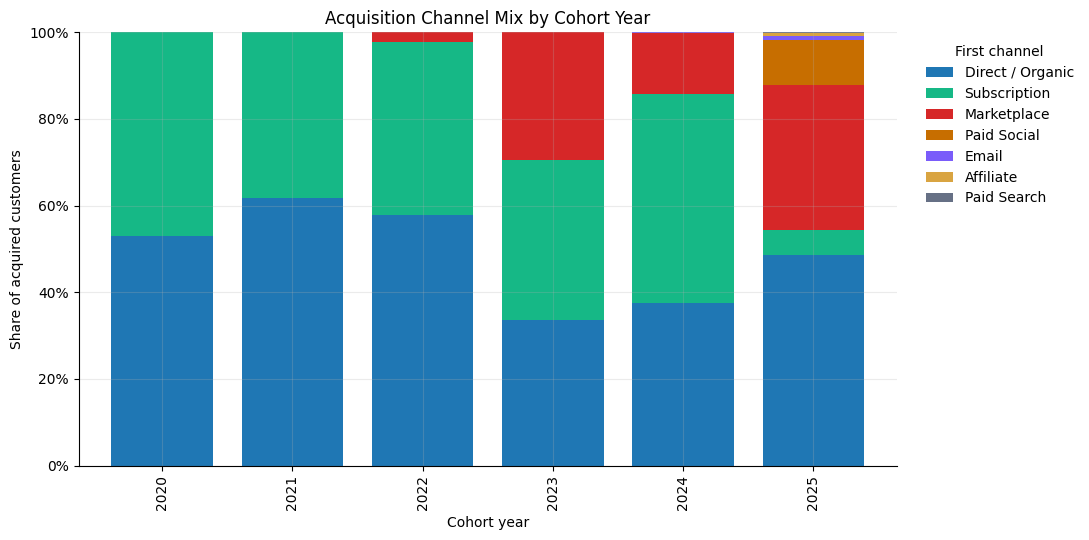

In [4]:
fig, ax = plt.subplots(figsize=(11, 5.5))
cohort_mix = channel_cohort_counts.T
cohort_mix_pct = cohort_mix.div(cohort_mix.sum(axis=1), axis=0)
plot_cols = [c for c in ["Direct / Organic", "Subscription", "Marketplace", "Paid Social", "Email", "Affiliate", "Paid Search"] if c in cohort_mix_pct.columns]
colors = [BLUE, TEAL, RED, ORANGE, PURPLE, GOLD, SLATE][:len(plot_cols)]
cohort_mix_pct[plot_cols].plot(kind="bar", stacked=True, ax=ax, color=colors, width=0.78)
ax.set_title("Acquisition Channel Mix by Cohort Year")
ax.set_xlabel("Cohort year")
ax.set_ylabel("Share of acquired customers")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.legend(title="First channel", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
fig.tight_layout()
plt.show()

## 3. Channel Quality: Same-Age Loyalty and Value

This is the main 365-day view for mature channels. It compares customers acquired from 2020-2024 and evaluates them within one year of first purchase.

Key loyalty signals:

- **Repeat 365d:** any second purchase within 365 days
- **Full-price repeat 365d:** a stricter loyalty signal, because the next order does not use a discount
- **Year-1 revenue/customer:** total first-year value per acquired customer

In [5]:
def channel_summary(df, eligibility_col="eligible_365d"):
    use = df[df[eligibility_col]].copy()
    summary = use.groupby("first_channel").agg(
        customers=("customer_id", "count"),
        cohort_year_min=("cohort_year", "min"),
        cohort_year_max=("cohort_year", "max"),
        repeat_180d=("repeat_180d", "mean"),
        repeat_365d=("repeat_365d", "mean"),
        full_price_repeat_365d=("full_price_repeat_365d", "mean"),
        avg_y1_revenue_sgd=("y1_revenue_sgd", "mean"),
        avg_y1_orders=("y1_orders", "mean"),
        avg_first_order_revenue_sgd=("first_order_revenue_sgd", "mean"),
        pct_first_order_discounted=("first_discounted", "mean"),
        avg_first_discount_depth=("first_discount_depth", "mean"),
        avg_y1_discounted_order_share=("y1_discounted_order_share", "mean"),
        avg_y1_discount_rate=("y1_discount_rate", "mean"),
    ).reset_index()
    summary["full_price_repeat_gap_pp"] = (summary["repeat_365d"] - summary["full_price_repeat_365d"]) * 100
    summary["discount_reliance_score"] = (
        0.35 * summary["pct_first_order_discounted"] +
        0.35 * summary["avg_y1_discounted_order_share"] +
        0.30 * summary["avg_y1_discount_rate"]
    )
    return summary.sort_values("customers", ascending=False)

mature_365 = cohort_features[cohort_features["cohort_year"].between(2020, 2024)].copy()
channel_365 = channel_summary(mature_365)
major_channel_365 = channel_365[channel_365["first_channel"].isin(MAJOR_MATURE_CHANNELS)].copy()

display_table(
    major_channel_365,
    {
        "customers": "{:,.0f}", "cohort_year_min": "{:.0f}", "cohort_year_max": "{:.0f}",
        "repeat_180d": "{:.1%}", "repeat_365d": "{:.1%}", "full_price_repeat_365d": "{:.1%}",
        "avg_y1_revenue_sgd": "S${:,.0f}", "avg_y1_orders": "{:.2f}", "avg_first_order_revenue_sgd": "S${:,.0f}",
        "pct_first_order_discounted": "{:.1%}", "avg_first_discount_depth": "{:.1%}",
        "avg_y1_discounted_order_share": "{:.1%}", "avg_y1_discount_rate": "{:.1%}",
        "full_price_repeat_gap_pp": "{:+.1f} pp", "discount_reliance_score": "{:.1%}",
    },
)

,first_channel,customers,cohort_year_min,cohort_year_max,repeat_180d,repeat_365d,full_price_repeat_365d,avg_y1_revenue_sgd,avg_y1_orders,avg_first_order_revenue_sgd,pct_first_order_discounted,avg_first_discount_depth,avg_y1_discounted_order_share,avg_y1_discount_rate,full_price_repeat_gap_pp,discount_reliance_score
0,Direct / Organic,"4,847",2020,2024,24.6%,29.5%,24.8%,S$184,1.76,S$87,20.4%,6.3%,20.8%,6.6%,+4.8 pp,16.4%
3,Subscription,"3,956",2020,2024,26.6%,31.7%,25.9%,S$250,1.76,S$116,25.9%,9.0%,25.6%,9.5%,+5.8 pp,20.9%
2,Marketplace,578,2022,2024,8.7%,11.4%,6.4%,S$67,1.18,S$55,62.6%,10.2%,63.4%,10.5%,+5.0 pp,47.3%


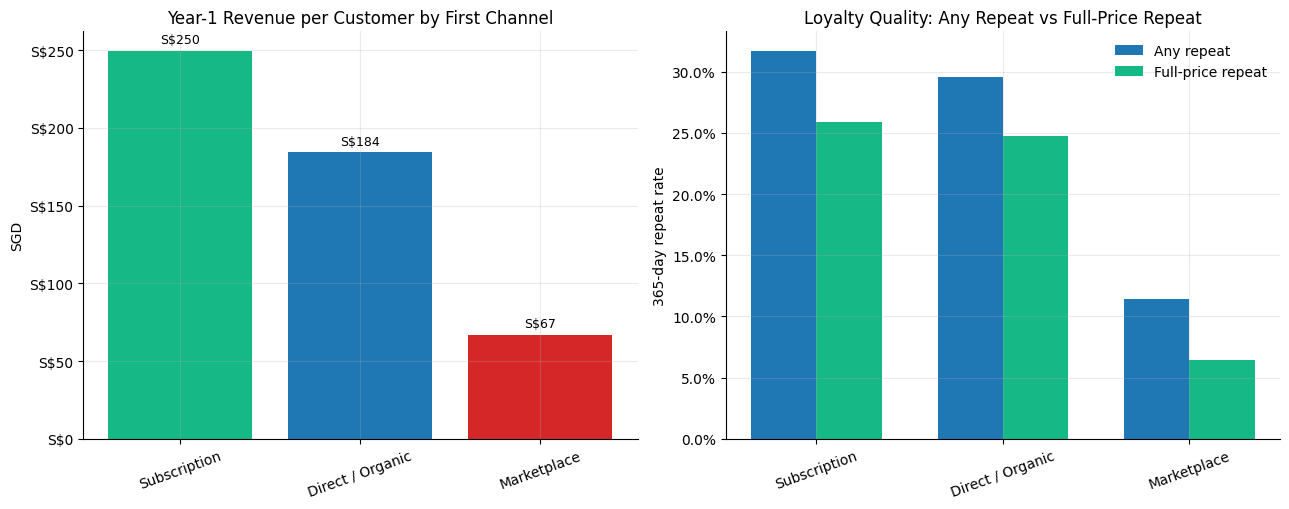

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))
plot = major_channel_365.sort_values("avg_y1_revenue_sgd", ascending=False)

axes[0].bar(plot["first_channel"], plot["avg_y1_revenue_sgd"], color=[TEAL, BLUE, RED][:len(plot)])
axes[0].set_title("Year-1 Revenue per Customer by First Channel")
axes[0].set_ylabel("SGD")
axes[0].yaxis.set_major_formatter(mticker.StrMethodFormatter("S${x:,.0f}"))
axes[0].tick_params(axis="x", rotation=20)
for i, v in enumerate(plot["avg_y1_revenue_sgd"]):
    axes[0].text(i, v + 5, f"S${v:,.0f}", ha="center", fontsize=9)

x = np.arange(len(plot))
w = 0.35
axes[1].bar(x - w/2, plot["repeat_365d"] * 100, width=w, color=BLUE, label="Any repeat")
axes[1].bar(x + w/2, plot["full_price_repeat_365d"] * 100, width=w, color=TEAL, label="Full-price repeat")
axes[1].set_xticks(x)
axes[1].set_xticklabels(plot["first_channel"], rotation=20)
axes[1].set_title("Loyalty Quality: Any Repeat vs Full-Price Repeat")
axes[1].set_ylabel("365-day repeat rate")
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter())
axes[1].legend(frameon=False)

fig.tight_layout()
plt.show()

## 4. Discount Utilization by Channel

This section answers: how often does each channel need discounts?

The clearest measures are:

- **% first orders discounted:** acquisition offer reliance
- **Average first discount depth:** how deep the acquisition discount is
- **% year-1 orders discounted:** whether the channel continues using discounts after acquisition
- **Year-1 discount rate:** discount dollars as a share of gross-before-discount first-year value

,first_channel,customers,pct_first_order_discounted,avg_first_discount_depth,avg_y1_discounted_order_share,avg_y1_discount_rate,full_price_repeat_gap_pp,discount_reliance_score
2,Marketplace,578,62.6%,10.2%,63.4%,10.5%,+5.0 pp,47.3%
3,Subscription,"3,956",25.9%,9.0%,25.6%,9.5%,+5.8 pp,20.9%
0,Direct / Organic,"4,847",20.4%,6.3%,20.8%,6.6%,+4.8 pp,16.4%


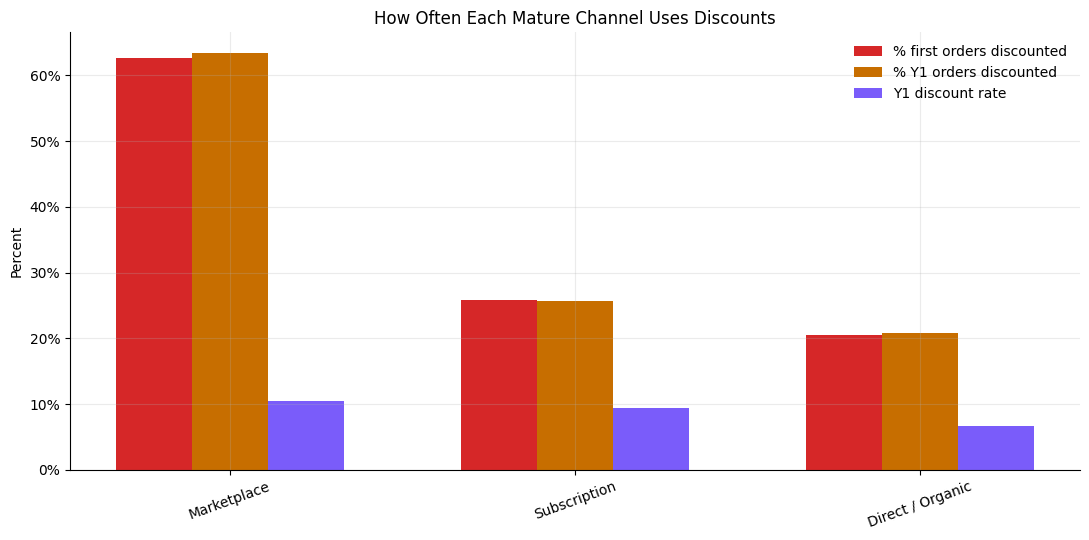

In [7]:
discount_usage = major_channel_365.sort_values("discount_reliance_score", ascending=False).copy()
display_table(
    discount_usage[[
        "first_channel", "customers", "pct_first_order_discounted", "avg_first_discount_depth",
        "avg_y1_discounted_order_share", "avg_y1_discount_rate", "full_price_repeat_gap_pp", "discount_reliance_score"
    ]],
    {
        "customers": "{:,.0f}", "pct_first_order_discounted": "{:.1%}", "avg_first_discount_depth": "{:.1%}",
        "avg_y1_discounted_order_share": "{:.1%}", "avg_y1_discount_rate": "{:.1%}",
        "full_price_repeat_gap_pp": "{:+.1f} pp", "discount_reliance_score": "{:.1%}",
    },
)

fig, ax = plt.subplots(figsize=(11, 5.5))
plot = discount_usage.copy()
x = np.arange(len(plot))
w = 0.22
ax.bar(x - w, plot["pct_first_order_discounted"] * 100, width=w, color=RED, label="% first orders discounted")
ax.bar(x, plot["avg_y1_discounted_order_share"] * 100, width=w, color=ORANGE, label="% Y1 orders discounted")
ax.bar(x + w, plot["avg_y1_discount_rate"] * 100, width=w, color=PURPLE, label="Y1 discount rate")
ax.set_xticks(x)
ax.set_xticklabels(plot["first_channel"], rotation=20)
ax.set_ylabel("Percent")
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.set_title("How Often Each Mature Channel Uses Discounts")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

## 5. Channel Quadrant: Loyalty vs Discount Reliance

This is the most compact strategic chart. Better channels sit high and left: higher full-price repeat, lower discount reliance. Channels sitting low and right are more discount-reliant and show weaker full-price loyalty.

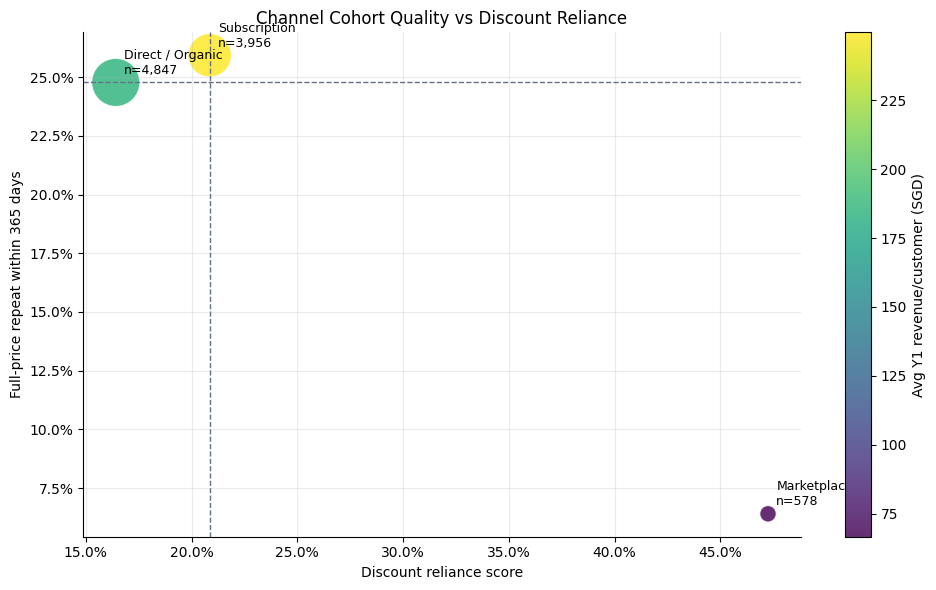

In [8]:
plot = major_channel_365.copy()
fig, ax = plt.subplots(figsize=(10, 6))
sc = ax.scatter(
    plot["discount_reliance_score"] * 100,
    plot["full_price_repeat_365d"] * 100,
    s=np.maximum(plot["customers"], 50) / 4,
    c=plot["avg_y1_revenue_sgd"],
    cmap="viridis",
    alpha=0.82,
    edgecolor="white",
    linewidth=1,
)
for _, row in plot.iterrows():
    ax.annotate(
        f"{row['first_channel']}\nn={row['customers']:,.0f}",
        (row["discount_reliance_score"] * 100, row["full_price_repeat_365d"] * 100),
        textcoords="offset points",
        xytext=(6, 6),
        fontsize=9,
    )
ax.axvline(plot["discount_reliance_score"].median() * 100, color=SLATE, linestyle="--", linewidth=1)
ax.axhline(plot["full_price_repeat_365d"].median() * 100, color=SLATE, linestyle="--", linewidth=1)
ax.set_xlabel("Discount reliance score")
ax.set_ylabel("Full-price repeat within 365 days")
ax.xaxis.set_major_formatter(mticker.PercentFormatter())
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.set_title("Channel Cohort Quality vs Discount Reliance")
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Avg Y1 revenue/customer (SGD)")
fig.tight_layout()
plt.show()

## 6. Cohort Trend by Channel

The next charts show how channel quality and discount reliance changed by acquisition cohort year. This is useful because the channel mix itself shifted over time.

In [9]:
channel_year = (
    mature_365[mature_365["eligible_365d"] & mature_365["first_channel"].isin(MAJOR_MATURE_CHANNELS)]
    .groupby(["cohort_year", "first_channel"])
    .agg(
        customers=("customer_id", "count"),
        repeat_365d=("repeat_365d", "mean"),
        full_price_repeat_365d=("full_price_repeat_365d", "mean"),
        avg_y1_revenue_sgd=("y1_revenue_sgd", "mean"),
        pct_first_order_discounted=("first_discounted", "mean"),
        avg_first_discount_depth=("first_discount_depth", "mean"),
        avg_y1_discounted_order_share=("y1_discounted_order_share", "mean"),
    )
    .reset_index()
)

display_table(
    channel_year.sort_values(["first_channel", "cohort_year"]),
    {
        "customers": "{:,.0f}", "repeat_365d": "{:.1%}", "full_price_repeat_365d": "{:.1%}",
        "avg_y1_revenue_sgd": "S${:,.0f}", "pct_first_order_discounted": "{:.1%}",
        "avg_first_discount_depth": "{:.1%}", "avg_y1_discounted_order_share": "{:.1%}",
    },
)

,cohort_year,first_channel,customers,repeat_365d,full_price_repeat_365d,avg_y1_revenue_sgd,pct_first_order_discounted,avg_first_discount_depth,avg_y1_discounted_order_share
0,2020,Direct / Organic,897,38.9%,38.9%,S$242,0.0%,0.0%,0.0%
2,2021,Direct / Organic,"2,049",29.1%,28.9%,S$197,0.0%,0.0%,0.3%
4,2022,Direct / Organic,854,27.6%,20.3%,S$213,15.8%,3.8%,19.3%
7,2023,Direct / Organic,293,19.8%,9.2%,S$87,74.4%,13.1%,73.6%
10,2024,Direct / Organic,754,25.5%,8.0%,S$87,84.6%,31.3%,82.3%
5,2022,Marketplace,34,32.4%,32.4%,S$115,5.9%,0.7%,5.9%
8,2023,Marketplace,257,8.9%,8.9%,S$71,46.7%,7.3%,47.1%
11,2024,Marketplace,287,11.1%,1.0%,S$57,83.6%,13.8%,84.8%
1,2020,Subscription,798,36.8%,36.8%,S$437,0.0%,0.0%,0.0%
3,2021,Subscription,"1,272",26.3%,26.3%,S$236,0.0%,0.0%,0.2%


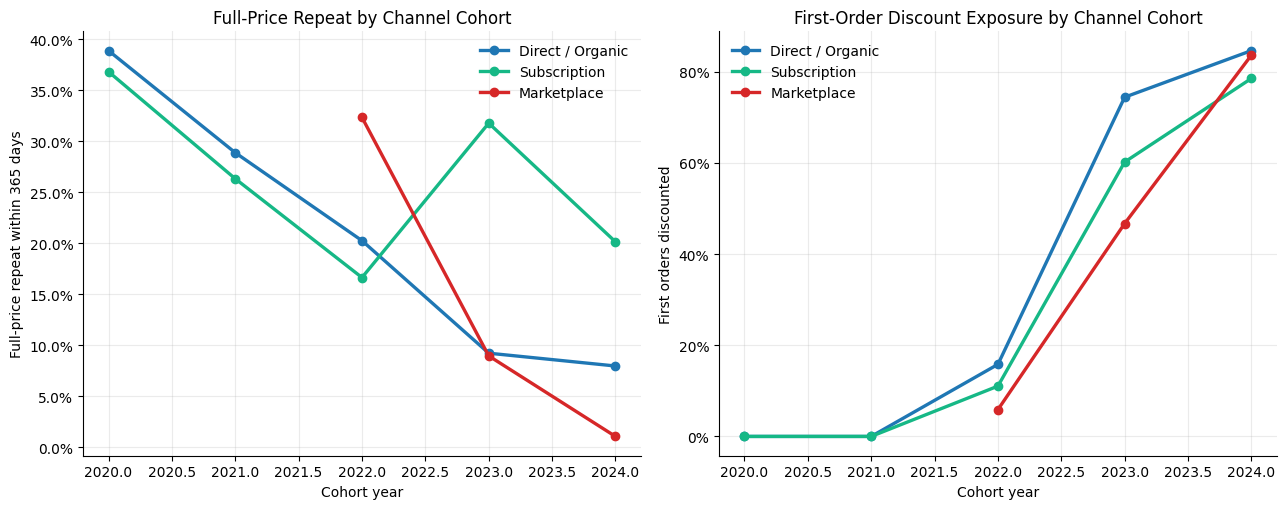

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.2), sharex=True)
channel_colors = {"Direct / Organic": BLUE, "Subscription": TEAL, "Marketplace": RED}
for ch in MAJOR_MATURE_CHANNELS:
    df = channel_year[channel_year["first_channel"].eq(ch)].sort_values("cohort_year")
    color = channel_colors.get(ch, SLATE)
    axes[0].plot(df["cohort_year"], df["full_price_repeat_365d"] * 100, marker="o", linewidth=2.4, label=ch, color=color)
    axes[1].plot(df["cohort_year"], df["pct_first_order_discounted"] * 100, marker="o", linewidth=2.4, label=ch, color=color)
axes[0].set_title("Full-Price Repeat by Channel Cohort")
axes[0].set_ylabel("Full-price repeat within 365 days")
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter())
axes[1].set_title("First-Order Discount Exposure by Channel Cohort")
axes[1].set_ylabel("First orders discounted")
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter())
for ax in axes:
    ax.set_xlabel("Cohort year")
    ax.legend(frameon=False)
fig.tight_layout()
plt.show()

## 7. Emerging Channels: Useful, but Not Yet Comparable on 365-Day Loyalty

Paid Social, Email, and Affiliate are mostly recent. Their 365-day read is based on few or no mature customers, so this notebook gives them a lighter-touch 180-day and acquisition-discount view.

In [11]:
emerging = cohort_features[cohort_features["first_channel"].isin(EMERGING_CHANNELS)].copy()
emerging_180 = emerging[emerging["eligible_180d"]].groupby("first_channel").agg(
    customers=("customer_id", "count"),
    latest_cohort=("cohort_year", "max"),
    repeat_180d=("repeat_180d", "mean"),
    full_price_repeat_180d=("full_price_repeat_180d", "mean"),
    avg_y180_revenue_sgd=("y180_revenue_sgd", "mean"),
    pct_first_order_discounted=("first_discounted", "mean"),
    avg_first_discount_depth=("first_discount_depth", "mean"),
    avg_y180_discounted_order_share=("y180_discounted_order_share", "mean"),
).reset_index().sort_values("customers", ascending=False)

display_table(
    emerging_180,
    {
        "customers": "{:,.0f}", "latest_cohort": "{:.0f}", "repeat_180d": "{:.1%}",
        "full_price_repeat_180d": "{:.1%}", "avg_y180_revenue_sgd": "S${:,.0f}",
        "pct_first_order_discounted": "{:.1%}", "avg_first_discount_depth": "{:.1%}",
        "avg_y180_discounted_order_share": "{:.1%}",
    },
)

,first_channel,customers,latest_cohort,repeat_180d,full_price_repeat_180d,avg_y180_revenue_sgd,pct_first_order_discounted,avg_first_discount_depth,avg_y180_discounted_order_share
3,Paid Social,305,2025,18.4%,13.8%,S$62,11.8%,1.5%,13.4%
1,Email,37,2025,10.8%,8.1%,S$24,67.6%,57.6%,65.9%
0,Affiliate,19,2025,26.3%,0.0%,S$99,100.0%,16.1%,100.0%
2,Paid Search,2,2025,50.0%,50.0%,S$100,0.0%,0.0%,0.0%


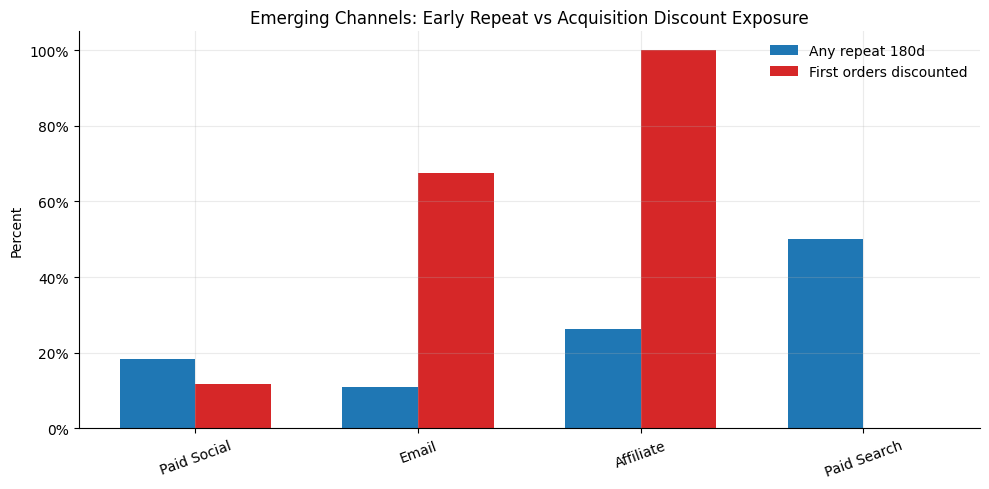

In [12]:
if len(emerging_180):
    fig, ax = plt.subplots(figsize=(10, 5))
    x = np.arange(len(emerging_180))
    w = 0.34
    ax.bar(x - w/2, emerging_180["repeat_180d"] * 100, width=w, color=BLUE, label="Any repeat 180d")
    ax.bar(x + w/2, emerging_180["pct_first_order_discounted"] * 100, width=w, color=RED, label="First orders discounted")
    ax.set_xticks(x)
    ax.set_xticklabels(emerging_180["first_channel"], rotation=20)
    ax.set_ylabel("Percent")
    ax.yaxis.set_major_formatter(mticker.PercentFormatter())
    ax.set_title("Emerging Channels: Early Repeat vs Acquisition Discount Exposure")
    ax.legend(frameon=False)
    fig.tight_layout()
    plt.show()
else:
    print("No emerging-channel customers are eligible for a 180-day read yet.")

## 8. Analytical Takeaways Before Building the Slide

This section turns the analysis into slide logic.

1. **Subscription is the quality anchor.** It has the strongest mature-channel quality profile: highest year-1 revenue/customer and highest full-price repeat within 365 days.
2. **Direct / Organic is the scale engine.** It has the largest mature customer base and decent full-price repeat, but recent cohorts show much heavier first-order discount usage than early cohorts.
3. **Marketplace is the caution zone.** In the Shopify-visible data, it has the weakest mature-channel loyalty profile: lowest year-1 revenue/customer, lowest full-price repeat, and highest discount reliance.
4. **Newer channels should not be over-interpreted yet.** Paid Social, Email, and Affiliate are mostly 2025-heavy, so they should be monitored with 180-day metrics until enough 365-day follow-up accumulates.

**Recommended dashboard metric:** track each channel by cohort month using a two-axis guardrail: `full_price_repeat_365d` for loyalty quality and `pct_first_order_discounted` / `y1_discount_rate` for discount reliance.

## Caveats

- This is descriptive analysis only; it compares observed customer behavior and does not estimate causal channel or discount effects.
- Marketplace and subscription behavior are Shopify-visible only; off-platform repeats may be undercounted.
- 2025-heavy channels have incomplete 365-day follow-up and are separated from the mature-channel comparison.
- Revenue and discount values inherit the project EDA pipeline's FX and cleaning assumptions.

## 9. What To Present: Follow-Up Slide Blueprint

### Slide Objective

The previous slide shows the macro problem: **more customers, lower revenue/customer, heavier discounting**. This follow-up slide explains **where the cohort-quality issue is showing up by acquisition channel**.

### Main Gist

**Not all growth is equal. Marketplace customers look materially weaker on full-price loyalty and year-1 value, while also being the most discount-reliant mature channel. Subscription remains the loyalty anchor, and Direct / Organic remains the scale channel to protect.**

### Suggested Slide Title

**Marketplace growth is discount-heavy and lower quality; Subscription remains the loyalty anchor**

Softer alternative:

**Channel mix shows where cohort quality is weakening**

### What To Put On The Slide

Use a two-chart layout similar to the original image.

| Slide element | What to show | Why it matters |
|---|---|---|
| Left chart: `Cohort Quality by Acquisition Channel` | Bars = year-1 revenue/customer; line = full-price repeat within 365 days. | Shows that Marketplace customers are lower-value and much less likely to repeat at full price. |
| Right chart: `Discount Utilization by Channel` | Bars = first orders discounted and year-1 orders discounted; line = discount reliance score. | Shows that Marketplace is not just lower-quality; it also depends more heavily on discounts. |
| Bottom callout box | 2-3 punchy bullets. | Connects the channel analysis back to the original discounting/cohort-quality slide. |

### Exact Chart References From This Notebook

| Message to present | Evidence from notebook | Best chart to use |
|---|---|---|
| Subscription is the strongest mature channel. | Highest year-1 revenue/customer and strongest full-price repeat among mature channels. | **Section 3: Year-1 Revenue per Customer by First Channel** and **Loyalty Quality: Any Repeat vs Full-Price Repeat** |
| Marketplace is the weakest mature channel in this data. | Lowest year-1 revenue/customer and lowest full-price repeat within 365 days. | **Section 3: Loyalty Quality: Any Repeat vs Full-Price Repeat** |
| Marketplace is also the most discount-reliant mature channel. | Highest first-order discount exposure, highest year-1 discounted-order share, and highest discount reliance score. | **Section 4: How Often Each Mature Channel Uses Discounts** |
| The clearest one-chart strategic summary is quality vs discount reliance. | It places channels by stricter loyalty signal and discount dependence at the same time. | **Section 5: Channel Cohort Quality vs Discount Reliance** |
| Recent cohorts need monitoring because discount use rose sharply. | Direct / Organic, Subscription, and Marketplace all show heavier first-order discounting in 2023-2024 than early cohorts. | **Section 6: Full-Price Repeat by Channel Cohort** and **First-Order Discount Exposure by Channel Cohort** |
| Newer channels are not yet fully comparable. | Paid Social, Email, and Affiliate are mostly 2025-heavy, so 180-day reads are more appropriate for now. | **Section 7: Emerging Channels: Early Repeat vs Acquisition Discount Exposure** |

**Safe wording:** use “associated with,” “looks weaker,” “shows lower full-price loyalty,” and “needs stricter payback guardrails.” Avoid claiming the channel or discounting caused the loyalty difference.

In [13]:

# Presentation-ready summary table from the mature-channel analysis.
presentation_summary = major_channel_365[[
    "first_channel", "customers", "avg_y1_revenue_sgd", "repeat_365d", "full_price_repeat_365d",
    "pct_first_order_discounted", "avg_y1_discounted_order_share", "avg_y1_discount_rate", "discount_reliance_score"
]].copy().sort_values("avg_y1_revenue_sgd", ascending=False)

# Add indexed metrics to make the story easy to compare on a slide.
best_y1 = presentation_summary["avg_y1_revenue_sgd"].max()
presentation_summary["y1_revenue_index_vs_best"] = presentation_summary["avg_y1_revenue_sgd"] / best_y1 * 100
presentation_summary["full_price_repeat_pp"] = presentation_summary["full_price_repeat_365d"] * 100
presentation_summary["discount_reliance_pp"] = presentation_summary["discount_reliance_score"] * 100

display_table(
    presentation_summary,
    {
        "customers": "{:,.0f}", "avg_y1_revenue_sgd": "S${:,.0f}", "repeat_365d": "{:.1%}",
        "full_price_repeat_365d": "{:.1%}", "pct_first_order_discounted": "{:.1%}",
        "avg_y1_discounted_order_share": "{:.1%}", "avg_y1_discount_rate": "{:.1%}",
        "discount_reliance_score": "{:.1%}", "y1_revenue_index_vs_best": "{:.0f}",
        "full_price_repeat_pp": "{:.1f}", "discount_reliance_pp": "{:.1f}",
    },
)

sub = presentation_summary[presentation_summary["first_channel"].eq("Subscription")].iloc[0]
dir_org = presentation_summary[presentation_summary["first_channel"].eq("Direct / Organic")].iloc[0]
market = presentation_summary[presentation_summary["first_channel"].eq("Marketplace")].iloc[0]

display(Markdown(
    f"**Presentation read:** Subscription leads on value at S${sub['avg_y1_revenue_sgd']:,.0f} Y1 revenue/customer and "
    f"{sub['full_price_repeat_365d']:.1%} full-price repeat. Direct / Organic is the scale channel with "
    f"{dir_org['customers']:,.0f} mature customers and {dir_org['full_price_repeat_365d']:.1%} full-price repeat. "
    f"Marketplace is the concern: S${market['avg_y1_revenue_sgd']:,.0f} Y1 revenue/customer, "
    f"{market['full_price_repeat_365d']:.1%} full-price repeat, and {market['discount_reliance_score']:.1%} discount reliance."
))


,first_channel,customers,avg_y1_revenue_sgd,repeat_365d,full_price_repeat_365d,pct_first_order_discounted,avg_y1_discounted_order_share,avg_y1_discount_rate,discount_reliance_score,y1_revenue_index_vs_best,full_price_repeat_pp,discount_reliance_pp
3,Subscription,"3,956",S$250,31.7%,25.9%,25.9%,25.6%,9.5%,20.9%,100,25.9,20.9
0,Direct / Organic,"4,847",S$184,29.5%,24.8%,20.4%,20.8%,6.6%,16.4%,74,24.8,16.4
2,Marketplace,578,S$67,11.4%,6.4%,62.6%,63.4%,10.5%,47.3%,27,6.4,47.3


**Presentation read:** Subscription leads on value at S$250 Y1 revenue/customer and 25.9% full-price repeat. Direct / Organic is the scale channel with 4,847 mature customers and 24.8% full-price repeat. Marketplace is the concern: S$67 Y1 revenue/customer, 6.4% full-price repeat, and 47.3% discount reliance.

## 10. Slide-Style Exhibit To Rebuild In The Deck

The chart below is intentionally structured like the original image: headline, two supporting charts, and a bottom interpretation band. It can be screenshotted as a draft or rebuilt manually in PowerPoint.

Recommended slide structure:

- **Headline:** Channel quality is uneven: Marketplace is discount-heavy and lower quality
- **Left chart:** Cohort quality by acquisition channel
- **Right chart:** Discount utilization by channel
- **Bottom box:** What this means for growth quality and retention strategy

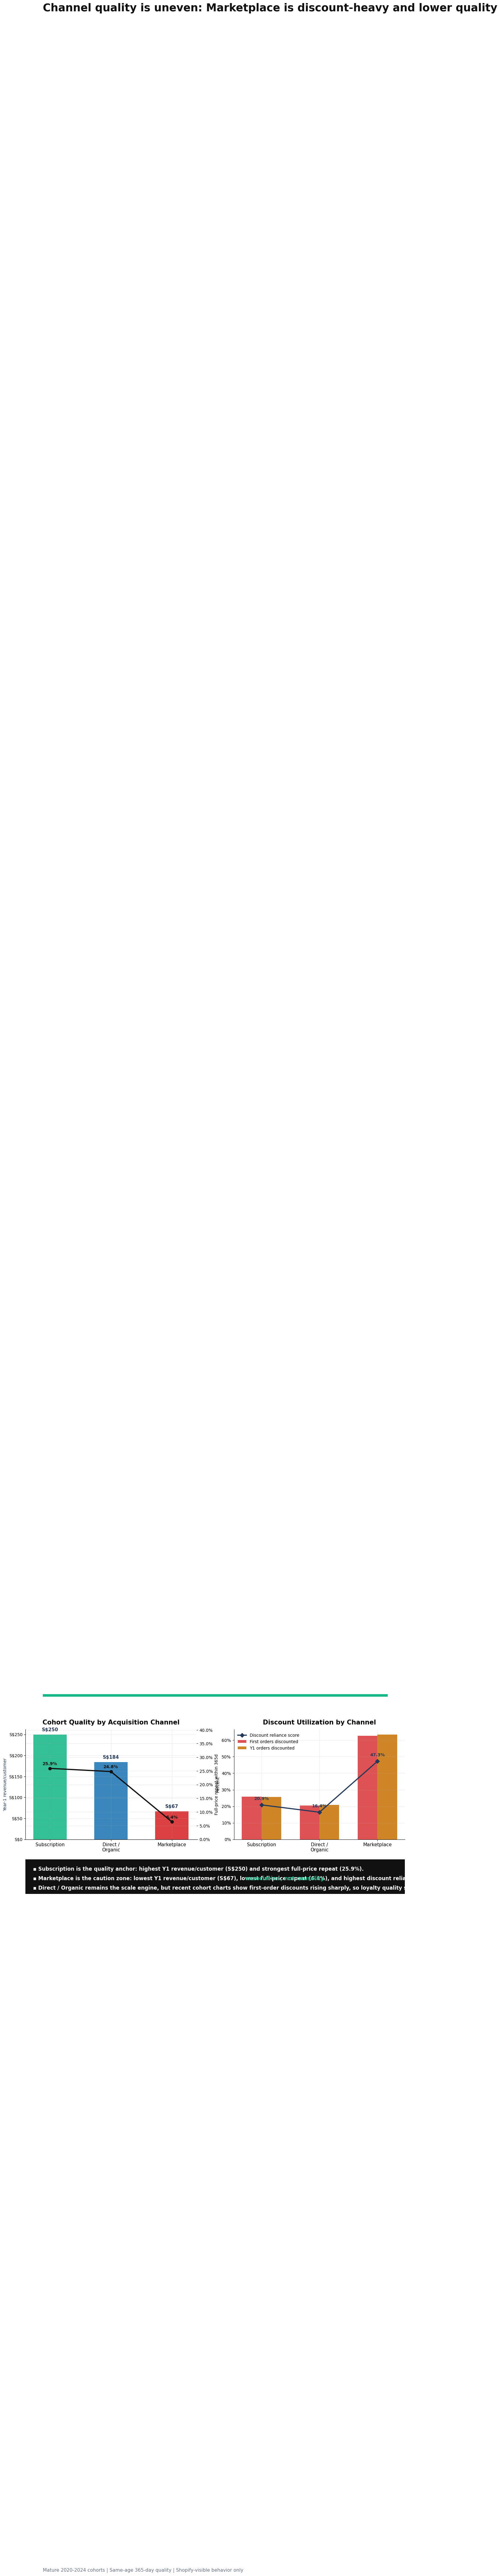

In [14]:

# Slide-style summary visual.
slide_df = presentation_summary.set_index("first_channel").loc[["Subscription", "Direct / Organic", "Marketplace"]].reset_index()
labels = ["Subscription", "Direct /\nOrganic", "Marketplace"]
x = np.arange(len(slide_df))

fig = plt.figure(figsize=(16, 9), facecolor="white")
gs = fig.add_gridspec(3, 2, height_ratios=[0.16, 0.64, 0.20], hspace=0.35, wspace=0.22)

# Title band
ax_title = fig.add_subplot(gs[0, :])
ax_title.axis("off")
ax_title.text(
    0.0, 0.62,
    "Channel quality is uneven: Marketplace is discount-heavy and lower quality",
    fontsize=25, fontweight="bold", color="#111111", va="center"
)
ax_title.plot([0.0, 0.14], [0.08, 0.08], color=TEAL, linewidth=6, solid_capstyle="butt")
ax_title.text(
    0.0, -0.20,
    "Mature 2020-2024 cohorts | Same-age 365-day quality | Shopify-visible behavior only",
    fontsize=11, color=SLATE, va="center"
)

# Left chart: value and loyalty
ax1 = fig.add_subplot(gs[1, 0])
bar_colors = [TEAL, BLUE, RED]
bars = ax1.bar(x, slide_df["avg_y1_revenue_sgd"], color=bar_colors, alpha=0.88, width=0.55, label="Y1 revenue/customer")
ax1.set_xticks(x)
ax1.set_xticklabels(labels, fontsize=11)
ax1.set_ylabel("Year-1 revenue/customer", color=NAVY)
ax1.yaxis.set_major_formatter(mticker.StrMethodFormatter("S${x:,.0f}"))
ax1.set_title("Cohort Quality by Acquisition Channel", fontsize=15, fontweight="bold", pad=12)
for bar, rev, fp in zip(bars, slide_df["avg_y1_revenue_sgd"], slide_df["full_price_repeat_365d"]):
    ax1.text(bar.get_x() + bar.get_width()/2, rev + 8, f"S${rev:,.0f}", ha="center", fontsize=11, fontweight="bold", color=NAVY)

ax1b = ax1.twinx()
ax1b.plot(x, slide_df["full_price_repeat_365d"] * 100, color="#111111", marker="o", linewidth=2.8, markersize=7, label="Full-price repeat")
ax1b.set_ylabel("Full-price repeat within 365d")
ax1b.yaxis.set_major_formatter(mticker.PercentFormatter())
ax1b.set_ylim(0, max(slide_df["full_price_repeat_365d"] * 100) * 1.55)
for xi, fp in enumerate(slide_df["full_price_repeat_365d"] * 100):
    ax1b.text(xi, fp + 1.2, f"{fp:.1f}%", ha="center", fontsize=10, color="#111111", fontweight="bold")

# Right chart: discount reliance
ax2 = fig.add_subplot(gs[1, 1])
w = 0.34
ax2.bar(x - w/2, slide_df["pct_first_order_discounted"] * 100, width=w, color=RED, alpha=0.80, label="First orders discounted")
ax2.bar(x + w/2, slide_df["avg_y1_discounted_order_share"] * 100, width=w, color=ORANGE, alpha=0.85, label="Y1 orders discounted")
ax2.plot(x, slide_df["discount_reliance_score"] * 100, color=NAVY, marker="D", linewidth=2.6, markersize=7, label="Discount reliance score")
ax2.set_xticks(x)
ax2.set_xticklabels(labels, fontsize=11)
ax2.set_ylabel("Percent")
ax2.yaxis.set_major_formatter(mticker.PercentFormatter())
ax2.set_title("Discount Utilization by Channel", fontsize=15, fontweight="bold", pad=12)
ax2.legend(frameon=False, loc="upper left", fontsize=10)
for xi, score in enumerate(slide_df["discount_reliance_score"] * 100):
    ax2.text(xi, score + 3, f"{score:.1f}%", ha="center", fontsize=10, color=NAVY, fontweight="bold")

# Bottom interpretation band
ax_note = fig.add_subplot(gs[2, :])
ax_note.set_facecolor("#111111")
ax_note.set_xticks([])
ax_note.set_yticks([])
for spine in ax_note.spines.values():
    spine.set_visible(False)

bullet_1 = (
    f"Subscription is the quality anchor: highest Y1 revenue/customer (S${sub['avg_y1_revenue_sgd']:,.0f}) "
    f"and strongest full-price repeat ({sub['full_price_repeat_365d']:.1%})."
)
bullet_2 = (
    f"Marketplace is the caution zone: lowest Y1 revenue/customer (S${market['avg_y1_revenue_sgd']:,.0f}), "
    f"lowest full-price repeat ({market['full_price_repeat_365d']:.1%}), and highest discount reliance ({market['discount_reliance_score']:.1%})."
)
bullet_3 = (
    "Direct / Organic remains the scale engine, but recent cohort charts show first-order discounts rising sharply, so loyalty quality should be monitored by cohort."
)
ax_note.text(0.02, 0.72, "▪ " + bullet_1, color="white", fontsize=12, fontweight="bold", va="center")
ax_note.text(0.02, 0.44, "▪ " + bullet_2, color="white", fontsize=12, fontweight="bold", va="center")
ax_note.text(0.02, 0.17, "▪ " + bullet_3, color="white", fontsize=12, fontweight="bold", va="center")
ax_note.text(0.58, 0.44, "association, not causality", color=TEAL, fontsize=13, fontweight="bold", va="center")

fig.tight_layout()
plt.show()


## 11. Speaker Notes: What To Say On The Slide

### 30-Second Version

“After seeing that revenue per customer fell while discounting rose, the next question is whether all customers are equally affected. The channel view shows they are not. Subscription is still the quality anchor, with the highest year-1 revenue per customer and strongest full-price repeat. Direct / Organic is the scale channel and performs reasonably well. Marketplace is the caution zone: it has the lowest year-1 revenue per customer, the lowest full-price repeat, and the highest discount reliance. So the issue is not just discounting in aggregate; it is where discounted acquisition is showing up and whether those customers come back without another offer.”

### Full Talk Track

1. **Bridge from prior slide.**
   “The previous slide showed the macro symptom: more customers, lower revenue per customer, and much heavier discounting. To understand the source of that quality issue, I broke the customer base down by first acquisition channel.”

2. **Explain the quality metric.**
   “I am not just using repeat rate, because a repeat order can still be discount-led. The stricter loyalty signal here is full-price repeat within 365 days.”

3. **Walk through the left chart.**
   “Subscription customers are the strongest: around S$250 in year-1 revenue per customer and 25.9% full-price repeat. Direct / Organic is also reasonably healthy at S$184 and 24.8%. Marketplace is much weaker at S$67 and only 6.4% full-price repeat.”

4. **Walk through the right chart.**
   “Marketplace is also the most discount-reliant mature channel. About 62.6% of Marketplace-acquired customers start with a discount, and 63.4% of their year-1 orders are discounted. Its discount reliance score is 47.3%, compared with 20.9% for Subscription and 16.4% for Direct / Organic.”

5. **Connect back to the original message.**
   “This supports the previous point in a more precise way: the business is not just acquiring more customers at lower average quality; the quality issue appears concentrated in channel mix and discount reliance.”

6. **End with the implication.**
   “The business should not evaluate growth only by customer count. It should ask which channels acquire customers who come back at full price. Subscription should be protected as the loyalty anchor, Direct / Organic should be optimized as the scale engine, and Marketplace needs stricter payback and retention guardrails.”

### Bottom-Box Bullets For The Slide

- **Subscription is the quality anchor:** highest year-1 revenue/customer and strongest full-price repeat.
- **Marketplace is the caution zone:** lowest year-1 revenue/customer, lowest full-price repeat, highest discount reliance.
- **Direct / Organic is the scale engine:** sizeable and decent quality, but recent cohorts need monitoring as discounts rise.

### One-Line Gist

**Not all customer growth is equal: the channels adding customers differ sharply in full-price loyalty and discount reliance.**

In [15]:
for name, path in DATA_SOURCES.items():
    lowered = str(path).lower()
    for forbidden in [("data", "gold"), ("data", "silver")]:
        assert "/".join(forbidden) not in lowered, path
print("Source-path guardrail passed: no forbidden prepared data paths configured.")

Source-path guardrail passed: no forbidden prepared data paths configured.
